# 🛒 Rossmann Store Sales Forecasting
## Notebook 2: Preprocessing & Feature Engineering

**Objective:** Clean missing values, engineer meaningful features, 
encode categorical variables, and prepare the final dataset for modelling.
All decisions are informed by findings from Notebook 01 EDA.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the merged cleaned df from EDA
train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])
store = pd.read_csv('../data/raw/store.csv')

# Reproduce the basic cleaning from Notebook 01 
df = train.merge(store, on='Store', how='left')
df = df[df['Open'] == 1].copy()
df = df[df['Sales'] > 0].copy()
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)
df['StateHoliday'] = df['StateHoliday'].astype(str).str.strip().replace({'0': 'None'})

print("Shape:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Shape: (844338, 18)
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


## 1. Handling Missing Values

Based on EDA findings, missing values fall into two categories:
- **Structural missingness** — missing because of business logic (Promo2 columns)
- **Random missingness** — genuinely unknown values (CompetitionDistance)

Each type requires a different imputation strategy.

In [2]:
# 1. CompetitionsDistance - impute with median (2,186 missing)
median_comp_dist = df['CompetitionDistance'].median()
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(median_comp_dist)

# 2. CompetitionOpenSince - fill with 0 (no competitor)
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)

# 3. Promo2 columns - structural missingness, fill with 0 or 'None' 
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna('None')

print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nNo missing values" if df.isnull().sum().sum() == 0 else "Still has missing values")

Missing values after imputation:
Series([], dtype: int64)

No missing values


## 2. Feature Engineering

We create four categories of features:
- **Calendar features** — extracted from the Date column
- **Competition features** — how long has competition been open
- **Promo features** — is store currently in Promo2 interval
- **Lag & Rolling features** — historical sales patterns

In [5]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfYear'] = df['Date'].dt.dayofyear
df['IsWeekend'] = df['DayOfWeek'].isin([6, 7]).astype(int)
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)

# December flag - we saw a strong December effect in the EDA
df['IsDecember'] = (df['Month'] == 12).astype(int)

print("Calendar features added!")
print(df[['Date', 'Year', 'Month', 'Day', 'WeekOfYear', 'DayOfYear', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'IsDecember']].head(10))

Calendar features added!
        Date  Year  Month  Day  WeekOfYear  DayOfYear  IsWeekend  \
0 2013-01-02  2013      1    2           1          2          0   
1 2013-01-03  2013      1    3           1          3          0   
2 2013-01-04  2013      1    4           1          4          0   
3 2013-01-05  2013      1    5           1          5          1   
4 2013-01-07  2013      1    7           2          7          0   
5 2013-01-08  2013      1    8           2          8          0   
6 2013-01-09  2013      1    9           2          9          0   
7 2013-01-10  2013      1   10           2         10          0   
8 2013-01-11  2013      1   11           2         11          0   
9 2013-01-12  2013      1   12           2         12          1   

   IsMonthStart  IsMonthEnd  IsDecember  
0             0           0           0  
1             0           0           0  
2             0           0           0  
3             0           0           0  
4             0 

In [9]:
# How many months has competition been open?
df['CompetitionOpen'] = (12 * (df['Year'] - df['CompetitionOpenSinceYear']) + (df['Month'] - df['CompetitionOpenSinceMonth']))

# Clip neagative values - competition not yet open
df['CompetitionOpen'] = df['CompetitionOpen'].clip(lower=0)

print("CompetitionOpen feature added!")
print(df[['Store', 'Date', 'CompetitionDistance', 'CompetitionOpenSinceYear', 'CompetitionOpen']].head(10))

CompetitionOpen feature added!
   Store       Date  CompetitionDistance  CompetitionOpenSinceYear  \
0      1 2013-01-02               1270.0                    2008.0   
1      1 2013-01-03               1270.0                    2008.0   
2      1 2013-01-04               1270.0                    2008.0   
3      1 2013-01-05               1270.0                    2008.0   
4      1 2013-01-07               1270.0                    2008.0   
5      1 2013-01-08               1270.0                    2008.0   
6      1 2013-01-09               1270.0                    2008.0   
7      1 2013-01-10               1270.0                    2008.0   
8      1 2013-01-11               1270.0                    2008.0   
9      1 2013-01-12               1270.0                    2008.0   

   CompetitionOpen  
0             52.0  
1             52.0  
2             52.0  
3             52.0  
4             52.0  
5             52.0  
6             52.0  
7             52.0  
8        

In [7]:
# Map PromoInterval to month numbers
promo_month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

def is_promo2_active(row):
    if row['Promo2'] == 0 or row['PromoInterval'] == 'None':
        return 0
    months = [promo_month_map[m] for m in row['PromoInterval'].split(',')]
    return 1 if row['Month'] in months else 0

df['IsPromo2Active'] = df.apply(is_promo2_active, axis=1)

print("Promo2 active feature added!")
print(df.groupby('IsPromo2Active')['Sales'].mean().round(2))

Promo2 active feature added!
IsPromo2Active
0    7052.21
1    6492.56
Name: Sales, dtype: float64


## 3. Lag and Rolling Features

Lag features capture the idea that **past sales predict future sales.**
Rolling statistics capture **recent trends and volatility.**

These are the most powerful features for tree-based models like LightGBM.

⚠️ Critical: Lag features must be created **within each store separately**
to avoid leakage between stores — Store 1's sales last week should not 
influence Store 2's features.

In [8]:
# Sort to ensure correct lag calculation
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# Create lag features within each store
lag_days = [1, 2, 3, 7, 14, 21, 28]
for lag in lag_days:
    df[f'Sales_Lag_{lag}'] = df.groupby('Store')['Sales'].shift(lag)

# Rolling statistics (7-day and 28-day windows)
df['Sales_RollingMean_7'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
df['Sales_Rollingmean_28'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(window=28, min_periods=1).mean())
df['Sales_RollingStd_7'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).std())

print("Lag and rolling features added!")
print("\nNew features:")
lag_cols = [c for c in df.columns if 'Lag' in c or 'Rolling' in c]
print(lag_cols)
print("\nMissing values from lag features")
print(df[lag_cols].isnull().sum())

Lag and rolling features added!

New features:
['Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_3', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Lag_21', 'Sales_Lag_28', 'Sales_RollingMean_7', 'Sales_Rollingmean_28', 'Sales_RollingStd_7']

Missing values from lag features
Sales_Lag_1              1115
Sales_Lag_2              2230
Sales_Lag_3              3345
Sales_Lag_7              7805
Sales_Lag_14            15610
Sales_Lag_21            23415
Sales_Lag_28            31220
Sales_RollingMean_7      1115
Sales_Rollingmean_28     1115
Sales_RollingStd_7       2230
dtype: int64


## 4. Handling Lag Feature Missing Values

Lag features produce NaN for the first n rows of each store — 
these are structurally missing because there is no historical data 
before the store's first observation. We drop these rows rather than 
imputing, since imputed lag values would be meaningless for modelling.

In [10]:
lag_cols = [c for c in df.columns if 'Lag' in c or 'Rolling' in c]

rows_before = len(df)
df = df.dropna(subset=lag_cols).reset_index(drop=True)
rows_after = len(df)

print(f"Rows before: {rows_before:,}")
print(f"Rows dropped: {rows_before - rows_after:,}")
print(f"Rows after: {rows_after:,}")
print(f"\nMissing values remaining: {df[lag_cols].isnull().sum().sum()}")

Rows before: 844,338
Rows dropped: 31,220
Rows after: 813,118

Missing values remaining: 0


### Observation: Lag Feature Missing Values

Dropping 31,220 rows — exactly 28 × 1,115 stores. This is purely 
structural missingness from the lag window, not a data quality issue. 
The first 28 days of each store have no complete lag history and are 
therefore unusable for lag-based modelling. We drop rather than impute 
since fabricated lag values would introduce noise into the most important 
features.

 ## 5. Encoding Categorical Variables

Tree-based models like LightGBM can handle label encoding directly.
For SARIMA we won't need these encodings.
We apply label encoding to: StoreType, Assortment, StateHoliday

In [12]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['StoreType', 'Assortment', 'StateHoliday']
le = LabelEncoder()

for col in cat_cols:
    df[col + '_Encoded'] = le.fit_transform(df[col].astype(str))
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} encoding: {mapping}")

StoreType encoding: {'a': np.int64(0), 'b': np.int64(1), 'c': np.int64(2), 'd': np.int64(3)}
Assortment encoding: {'a': np.int64(0), 'b': np.int64(1), 'c': np.int64(2)}
StateHoliday encoding: {'None': np.int64(0), 'a': np.int64(1), 'b': np.int64(2), 'c': np.int64(3)}


### Observation: Categorical Encoding

Label encoding applied to StoreType, Assortment and StateHoliday:
- StoreType: a=0, b=1, c=2, d=3
- Assortment: a=0, b=1, c=2
- StateHoliday: None=0, a=1, b=2, c=3

Note: Label encoding is appropriate here for tree-based models 
(LightGBM) which split on numeric thresholds and can handle ordinal-like 
encodings. For linear models, one-hot encoding would be more appropriate 
to avoid implying ordinal relationships between categories.

## 6. Log Transformation of Target Variable

As established in EDA, Sales are right-skewed (skewness=1.595) and 
show multiplicative seasonality. Log transformation:
1. Normalizes the distribution
2. Converts multiplicative seasonality to additive
3. Makes RMSE-based optimization equivalent to MAPE minimization

We create LogSales as our modelling target and will back-transform 
predictions using exp() for evaluation.

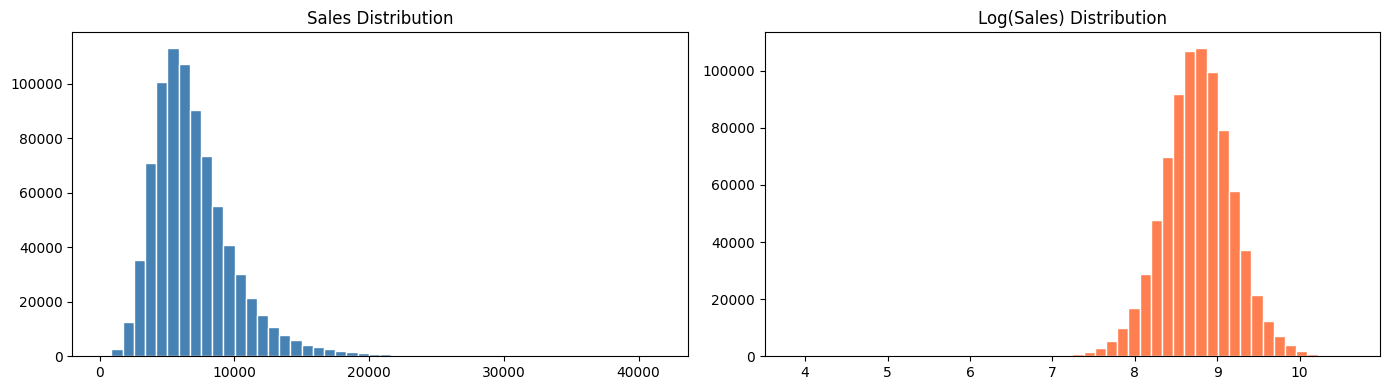

Sales skewness    : 1.5926
LogSales skewness : -0.1042


In [13]:
df['LogSales'] = np.log1p(df['Sales'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution')
axes[1].hist(df['LogSales'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log(Sales) Distribution')
plt.tight_layout()
plt.savefig('../reports/07_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sales skewness    : {df['Sales'].skew():.4f}")
print(f"LogSales skewness : {df['LogSales'].skew():.4f}")

### Observation: Log Transformation

Sales skewness reduced from 1.593 (strongly right-skewed) to -0.104 
(approximately normal) after log transformation. This confirms log(Sales) 
as the appropriate modelling target.

Three benefits of modelling LogSales:
1. Normalizes the skewed distribution — improves model stability
2. Converts multiplicative seasonality to additive — as shown in STL analysis
3. Makes percentage errors symmetric — RMSE on log scale approximates MAPE

All model predictions will be in log scale and back-transformed 
using expm1() for final evaluation.

## 7. Train/Validation Split

We use a time-based split — the last 6 weeks of data are held out 
as validation. This mimics real forecasting conditions where the model 
is always trained on the past and evaluated on the future.

❌ Random splitting is strictly forbidden for time series — it causes 
data leakage where future information contaminates the training set.

In [14]:
split_date = '2015-06-15'

train_df = df[df['Date'] < split_date].copy()
val_df = df[df['Date'] >= split_date].copy()

print(f"Split date        : {split_date}")
print(f"Train set         : {train_df['Date'].min().date()} → {train_df['Date'].max().date()}")
print(f"Validation set    : {val_df['Date'].min().date()} → {val_df['Date'].max().date()}")
print(f"Train size        : {len(train_df):,} rows")
print(f"Validation size   : {len(val_df):,} rows")
print(f"Validation %      : {len(val_df)/len(df)*100:.1f}%")

Split date        : 2015-06-15
Train set         : 2013-01-29 → 2015-06-14
Validation set    : 2015-06-15 → 2015-07-31
Train size        : 767,266 rows
Validation size   : 45,852 rows
Validation %      : 5.6%


### Observation: Train/Validation Split

A time-based split is used — all data before June 15, 2015 for training 
and the remaining 6 weeks for validation.

- Train: Jan 2013 → Jun 2015 (767,266 rows, 94.4%)
- Validation: Jun 2015 → Jul 2015 (45,852 rows, 5.6%)

Random splitting is strictly avoided for time series data as it causes 
data leakage — future observations would contaminate the training set, 
producing artificially optimistic evaluation metrics that don't reflect 
real forecasting performance.

The 6-week validation window was chosen to:
1. Cover at least one full seasonal cycle (weekly s=7)
2. Represent a realistic forecasting horizon for retail operations
3. Include enough rows (45,852) for statistically meaningful evaluation

In [16]:
df.to_csv('../data/processed/df_processed.csv', index=False)
train_df.to_csv('../data/processed/train_processed.csv', index=False)
val_df.to_csv('../data/processed/val_processed.csv', index=False)

print("Saved successfully ✅")
print(f"Final dataset shape : {df.shape}")
print(f"\nFinal feature list:")
print([c for c in df.columns if c not in 
       ['Store', 'Date', 'Sales', 'Customers', 'Open']])

Saved successfully ✅
Final dataset shape : (813118, 43)

Final feature list:
['DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'WeekOfYear', 'DayOfYear', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'IsDecember', 'CompetitionOpen', 'IsPromo2Active', 'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_3', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Lag_21', 'Sales_Lag_28', 'Sales_RollingMean_7', 'Sales_Rollingmean_28', 'Sales_RollingStd_7', 'StoreType_Encoded', 'Assortment_Encoded', 'StateHoliday_Encoded', 'LogSales']


## Summary: Preprocessing Complete

Final processed dataset: 813,118 rows × 43 columns

### Changes made from raw data:
1. **Missing values** — median imputation for CompetitionDistance, 
   zero-fill for structural Promo2 missingness
2. **StateHoliday** — standardized encoding inconsistency (string/int 0)
3. **Calendar features** — Year, Month, Day, WeekOfYear, IsWeekend, 
   IsMonthStart, IsMonthEnd, IsDecember
4. **Competition feature** — CompetitionOpen (months competitor has been open)
5. **Promo2 feature** — IsPromo2Active (binary flag for active promo month)
6. **Lag features** — Sales at lags 1, 2, 3, 7, 14, 21, 28 days
7. **Rolling features** — 7-day and 28-day rolling mean and std
8. **Encoding** — Label encoding for StoreType, Assortment, StateHoliday
9. **Log transform** — LogSales as modelling target (skewness: 1.59 → -0.10)
10. **Train/val split** — Time-based split at June 15, 2015

### Key finding from feature engineering:
Promo2 active days show **lower** average sales (6,492) vs non-active 
days (7,052) — suggesting selection bias where naturally lower-performing 
stores rely more heavily on recurring promotions.

### Next: Notebook 03 — Classical Models (SARIMA, SARIMAX)